# 深度卷积网络AlexNet

In [9]:
import torch
import torch.nn as nn
from d2l import torch as d2l

net = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(96, 256,kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(), nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(p=0.5),
    nn.Linear(4096, 10)
)

## 我们构造一个单通道数据，来观察每一层输出的形状

In [10]:
X = torch.randn(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

## fashion-Mnist 图像分辨率小于 ImageNet图像。我们将他增加到224x224

In [11]:
batch_size = 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

## 训练AlexNet

loss 0.330, train acc 0.879, test acc 0.882
68.9 examples/sec on mps


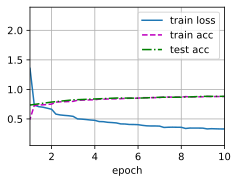

In [12]:
lr, num_epochs = 0.01, 10
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)
# 由于AlexNet参数量大，训练时间较长，建议使用GPU训练
# net = net.to(d2l.try_gpu())
# d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

# 使用块的网络 VGG

In [14]:
def vgg_block(num_convs, in_channels, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)) 
        layers.append(nn.ReLU())
        in_channels = out_channels
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

## VGG网络

In [15]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

def vgg(conv_arch):
    conv_blocks = []
    in_channels = 1
    for (num_convs, out_channels) in conv_arch:
        conv_blocks.append(vgg_block(num_convs, in_channels, out_channels))
        in_channels = out_channels
    
    return nn.Sequential(
        *conv_blocks, nn.Flatten(),
        nn.Linear(in_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(p=0.5),
        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(p=0.5),
        nn.Linear(4096, 10)
    )

net = vgg(conv_arch)

### 观察每一层的输出形状

In [16]:
X = torch.randn(size=(1, 1, 224, 224))
for block in net:
    X = block(X)
    print(block.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


## 由于VGG-11比AlexNet计算量更大，因此我们构建了一个通道数较少的网络

In [17]:
ratio = 4
small_conv_arch = [(pair[0], pair[1]//ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

### 模型训练

loss 0.178, train acc 0.934, test acc 0.917
109.8 examples/sec on mps


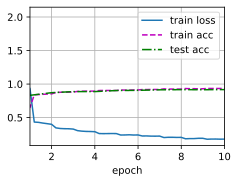

In [19]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, device)
# 由于VGG-11比AlexNet计算量更大，因此我们构建了一个通道数较少的网络
# net = net.to(d2l.try_gpu())
# d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())